## IN_DATA
- `dat_traj`

## OUT_DATA
- `dat_map_{job}`

## VERSION

## PACKAGE

In [97]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.metadata import *
from src.sparsemap import *

warnings.filterwarnings("ignore", category=RuntimeWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BASH PARAMETERS

In [98]:
job_id = 72#int(sys.argv[1])

In [99]:
in_dir = project_dir / "results"
# out_dir = project_dir / "results" / "data_map"
#
# if not os.path.exists(out_dir):
#     os.makedirs(out_dir)

In [100]:
# load tile trajectories
dat_traj_dict = pickle.load(open(in_dir / "dat_traj_dict", "rb"))

## JOB BATCHES

In [101]:
# override
mouse_ids = [3]
n_mice = len(mouse_ids)

In [102]:
# OPTIMAL MAP BATCH
seed_list = np.arange(n_seeds_traj)
rotation_id_list = np.arange(6)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,seed,-1), pi_lev) for pi_lev in pi_level_list for seed in seed_list]

job_list_all_mice = []
for mouse_id in mouse_ids:
    job_list_mouse = [((1,mouse_id,rot_id), pi_lev) for pi_lev in pi_level_list for rot_id in rotation_id_list]
    job_list_all_mice.extend(job_list_mouse)

# pack
job_batch_optmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_all_mice)}

# print
len(job_batch_optmap)

160

In [103]:
# RANDOM MAP BATCH: 10 pi_level, 2 mice x 5 random maps + 5 random trajectories x 5 random maps (350 jobs)
traj_seed_list = np.arange(n_seeds_traj)
map_seed_list = np.arange(n_seeds_map)
pi_level_list = np.arange(0, 91, 10)

# get job lists
job_list_rand = [((0,traj_seed,-1), pi_lev, map_seed) for pi_lev in pi_level_list for traj_seed in traj_seed_list for map_seed in map_seed_list]
#
job_list_all_mice = []
for mouse_id in mouse_ids:
    job_list_mouse = [((1,mouse_id,0), pi_lev, map_seed) for pi_lev in pi_level_list for map_seed in map_seed_list]
    job_list_all_mice.extend(job_list_mouse)

# pack
job_batch_randmap = {i+1: job for i, job in enumerate(job_list_rand + job_list_all_mice)}
len(job_batch_randmap)

1100

## LOCAL PARAMETERS

In [104]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']

## PREP
### setting up belief distribution propagation

In [105]:
# prep: maze dictionaries
hex_0_grid, hex_1_grid, s_z_dict, s_hex_dict, hex_a_dict, xy_s_dict, a_dict, sas_dict, ssa_dict, s_nbr_dict = load_maze_dicts(maze)

# prep: map
e_sh_arr = get_e_sh_arr(n_tiles, ringsize)
eid_wall, sh_wall, n_edges_wall = get_eid_wall(sas_dict, ringsize, n_tiles, e_sh_arr)
sh_dz_arr = get_sh_dz_arr(s_z_dict, sas_dict, sh_wall)
pq_mask_amb_dict = get_pq_mask_dict_for_ambiguous_edges(sh_dz_arr)

# prep: pi & tile transition tensor
pi_all = get_p_vonmises_for_enumPI()
T = get_T_tensor(sas_dict, ringsize, n_tiles)
T_dict = get_T_tensor_dict(T, ringsize)

### job batches

In [106]:
# init
label_list = ['optmap, mouse', 'optmap, rotated mouse', 'optmap, random walk', 'randmap, mouse', 'randmap, random walk']
score_tensor_list = []

In [107]:
load_dir = project_dir / "results" / "data_optmap"

# 'optmap, mouse'
job_id_select = [x for x,((y,z,w),u) in job_batch_optmap.items() if w==0]
score_tensor = np.array([pickle.load(open(load_dir / f"dat_map_{job_batch_optmap[job_id]}", "rb"))[0] for job_id in job_id_select])[:,::-1].reshape(n_mice,10,-1)
score_tensor = np.transpose(score_tensor, (1,0,2))
score_tensor_list.append(score_tensor)

# 'optmap, rotated mouse'
job_id_select = [x for x,((y,z,w),u) in job_batch_optmap.items() if w>0]
score_tensor = np.array([pickle.load(open(load_dir / f"dat_map_{job_batch_optmap[job_id]}", "rb"))[0] for job_id in job_id_select])[:,::-1].reshape(n_mice,10,5,-1)
# score_tensor = np.transpose(score_tensor, (1,0,2,3)).reshape(10,10,-1)
score_tensor = np.transpose(score_tensor, (1,0,2,3)).reshape(10,n_mice*5,-1)
score_tensor_list.append(score_tensor)

# 'optmap, random walk'
job_id_select = np.arange(1,101)
score_tensor = np.array([pickle.load(open(load_dir / f"dat_map_{job_batch_optmap[job_id]}", "rb"))[0] for job_id in job_id_select])[:,::-1].reshape(10,n_seeds_traj,-1)
score_tensor_list.append(score_tensor)

In [108]:
load_dir = project_dir / "results" / "data_randmap"

# 'randmap, mouse'
job_id_select = [x for x,((y,z,w),u,v) in job_batch_randmap.items() if y==1]
score_tensor = np.array([pickle.load(open(load_dir / f"dat_map_{job_batch_randmap[job_id]}", "rb"))[0] for job_id in job_id_select])[:,::-1].reshape(n_mice,10,n_seeds_map,-1)
score_tensor = np.transpose(score_tensor, (1, 0, 2, 3)).reshape(10, n_mice*n_seeds_map, -1)
score_tensor_list.append(score_tensor)

# 'randmap, random walk'
job_id_select = [x for x,((y,z,w),u,v) in job_batch_randmap.items() if y==0]
score_tensor = np.array([pickle.load(open(load_dir / f"dat_map_{job_batch_randmap[job_id]}", "rb"))[0] for job_id in job_id_select])[:,::-1].reshape(10,n_seeds_traj*n_seeds_map,-1)
score_tensor_list.append(score_tensor)

## FIGURE: performance curves

In [109]:
score_tensor.shape

(10, 100, 931)

In [110]:
# # plot 10s
# plt.figure(figsize=(14, 9), dpi=200)
# for k, (score_tensor, label) in enumerate(zip(score_tensor_list, label_list)):
#     plt.subplot(2, 3, k+1)
#     plt.title(f'{label}')
#     for i,x in enumerate(score_tensor):
#         # load sublabels
#         if label=='optmap, mouse':
#             sublabels = [f'PI fidelity={i*10}'] + ['']*(n_mice-1)
#         elif label=='optmap, rotated mouse':
#             sublabels = [f'PI fidelity={i*10}'] + ['']*(n_mice*5-1)
#         elif label=='optmap, random walk':
#             sublabels = [f'PI fidelity={i*10}'] + ['']*(n_seeds_traj-1)
#         elif label=='randmap, mouse':
#             sublabels = [f'PI fidelity={i*10}'] + ['']*(n_mice*n_seeds_map-1)
#         elif label=='randmap, random walk':
#             sublabels = [f'PI fidelity={i*10}'] + ['']*(n_seeds_traj*n_seeds_map-1)
        
#         # plot
#         plt.plot(x.T, label=sublabels, color=colors[i])
#     for y,c in zip([.6,.7], ['dimgray', 'k']): 
#         plt.axhline(y, color=c, linestyle='--', lw=1)
#     plt.xlabel('map size (# edges)')
#     plt.ylabel('average score')
#     plt.legend()
#     plt.grid(alpha=.2)
    
# plt.tight_layout()

## FIGURE: tradeoff curves

In [111]:
score_tar = .7

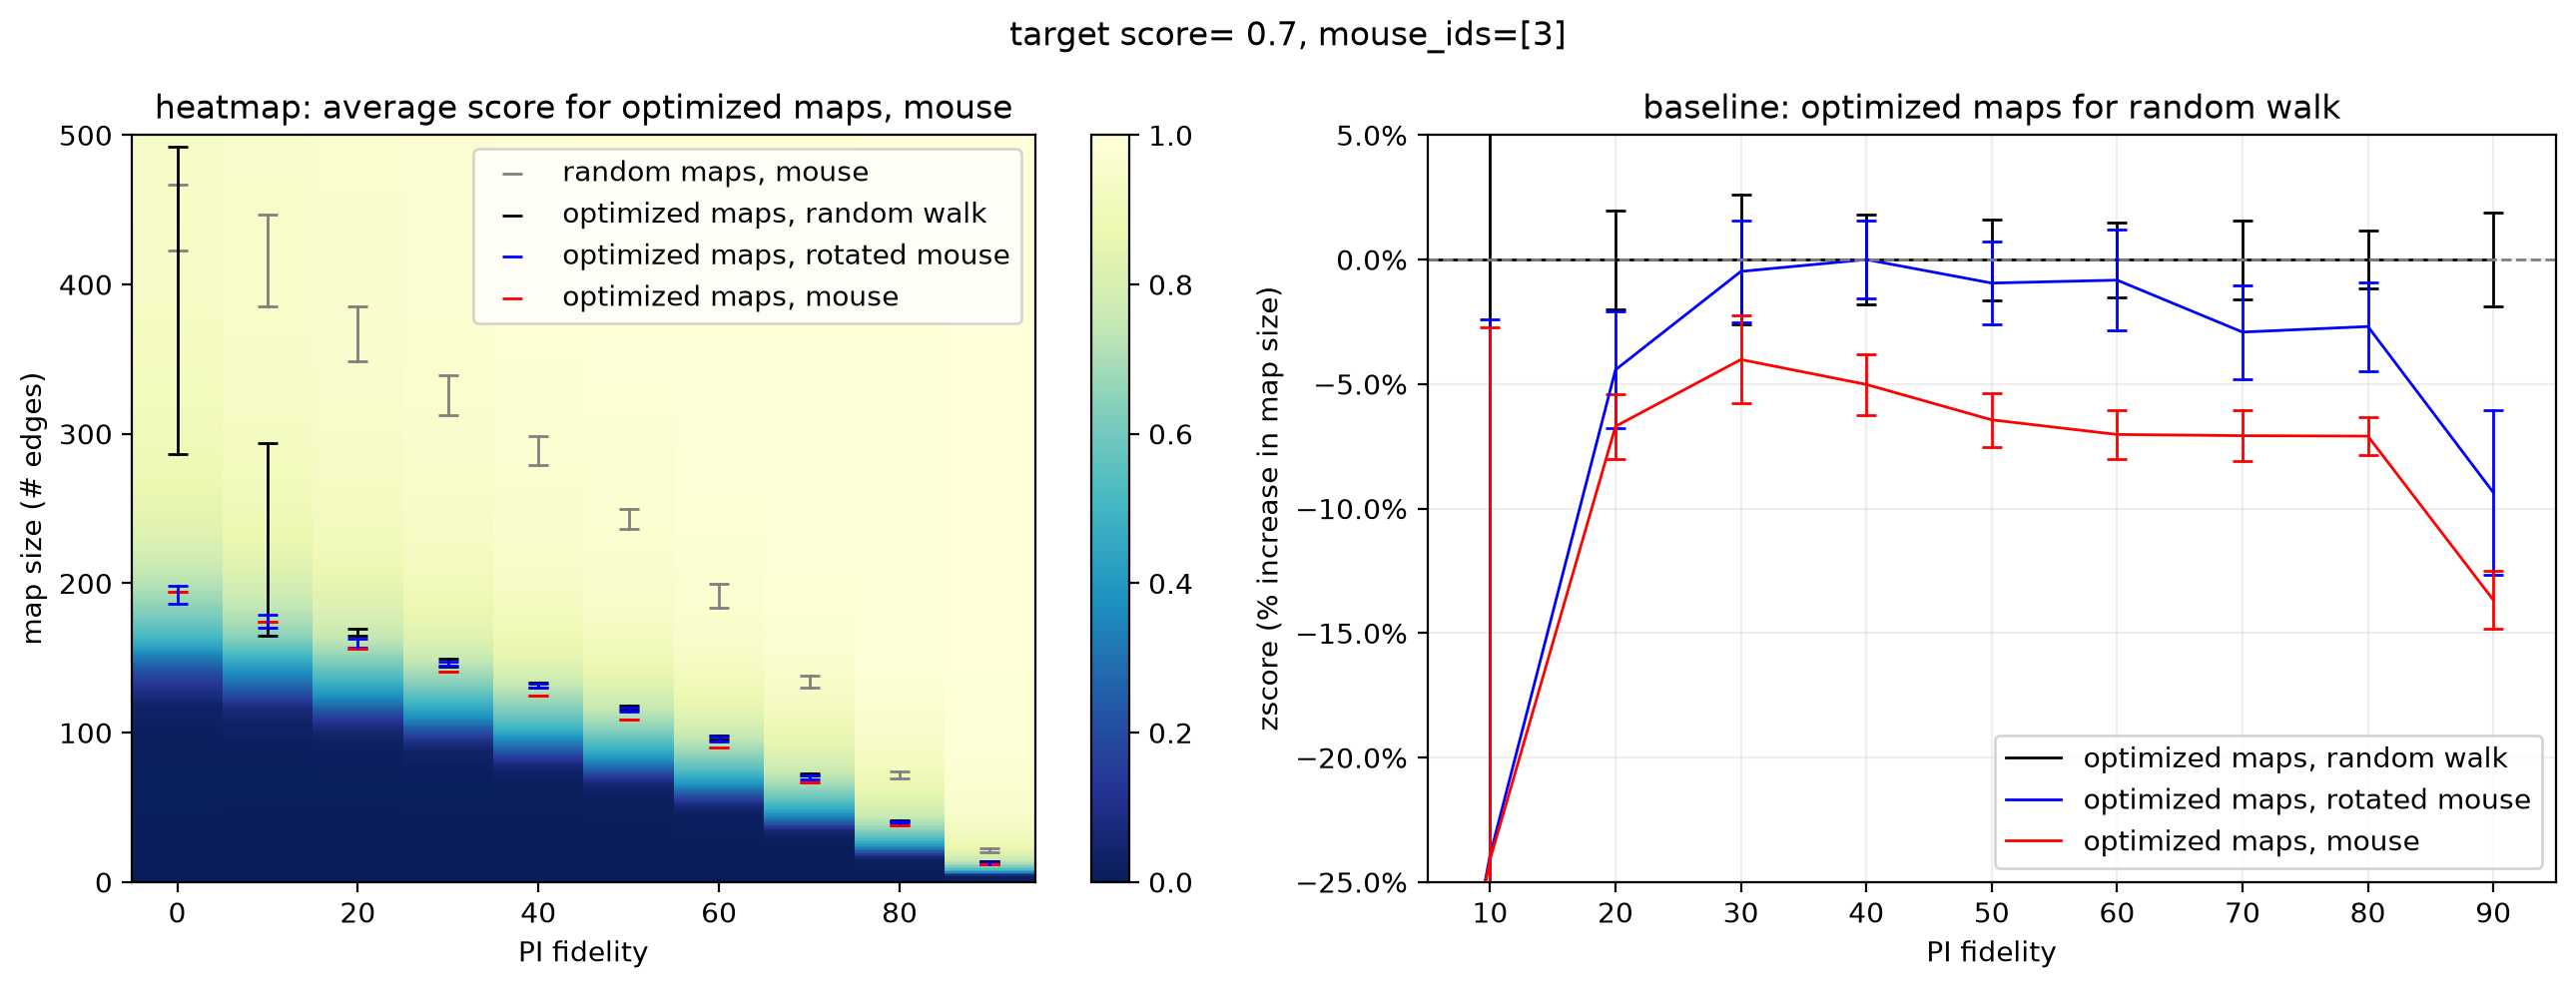

In [112]:
## HEATMAP
# prep: tradeoff curves
score_tensor_select = [score_tensor_list[x] for x in [3, 2, 1, 0]]
label_select = ['random maps, mouse', 'optimized maps, random walk', 'optimized maps, rotated mouse', 'optimized maps, mouse']
color_select = ['gray', 'k', 'b', 'r']

# prep: heatmap
score_arr = score_tensor_select[-1].mean(1)

# plot
plt.figure(figsize=(13,5), dpi=200)
# plt.suptitle(f'n_mice={n_mice}, target score= {score_tar}')
plt.suptitle(f'target score= {score_tar}, mouse_ids={mouse_ids}')

plt.subplot(121)
plt.title(f'heatmap: average score for {label_select[-1]}')
plt.imshow(score_arr.T, aspect='auto', cmap='YlGnBu_r', origin='lower', vmin=0, vmax=1, interpolation='nearest', extent=[pi_level_list[0]-5, pi_level_list[-1]+5, 0, score_arr.shape[1]])
plt.colorbar()

for i, (score_tensor, label, color) in enumerate(zip(score_tensor_select, label_select, color_select)):
    mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
    mapsize_ci, mapsize_mean, _ = get_confidence_interval(mapsize_arr, axis=1)
    #
    for pi, ci0, ci1 in zip(pi_level_list, mapsize_mean-mapsize_ci, mapsize_mean+mapsize_ci):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, mapsize_mean-mapsize_ci, color=color, s=50, label=f'{label}', marker='_', lw=1)
    plt.scatter(pi_level_list, mapsize_mean+mapsize_ci, color=color, s=50, marker='_', lw=1)

# setting
plt.xlabel('PI fidelity')
plt.ylabel('map size (# edges)')
plt.legend()
plt.ylim([0, 500])


## TRADEOFF CURVES
# prep: tradeoff curves
score_tensor_select = [score_tensor_list[x] for x in [2,1,0]]
label_select = ['optimized maps, random walk', 'optimized maps, rotated mouse', 'optimized maps, mouse']
color_select = ['k', 'b', 'r']

# baseline
mapsize_arr_rw = np.argmin(np.abs(score_tensor_select[0]-score_tar), axis=-1)
mapsize_ci_rw, mapsize_mean_rw, _ = get_confidence_interval(mapsize_arr_rw, axis=1)

# plot
plt.subplot(122)
plt.title(f'baseline: optimized maps for random walk')
for i, (score_tensor, label, color) in enumerate(zip(score_tensor_select, label_select, color_select)):
    mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
    mapsize_ci, mapsize_mean, _ = get_confidence_interval(mapsize_arr, axis=1)
    
    # z-score
    zscore = (mapsize_mean - mapsize_mean_rw) / mapsize_mean_rw
    
    # uncertainty propagation
    # z_ci = np.sqrt((mapsize_ci / mapsize_mean_rw)**2 + (mapsize_mean * mapsize_ci_rw / mapsize_mean_rw**2)**2)
    
    z_ci = (1+zscore) * np.sqrt((mapsize_ci / mapsize_mean)**2 + (mapsize_ci_rw / mapsize_mean_rw)**2)
    
    # iter
    plt.plot(pi_level_list, zscore, color=color, lw=1, label=label)
    for pi, ci0, ci1 in zip(pi_level_list, zscore-z_ci, zscore+z_ci):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, zscore-z_ci, color=color, s=50, marker='_', lw=1)
    plt.scatter(pi_level_list, zscore+z_ci, color=color, s=50, marker='_', lw=1)
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.xlabel('PI fidelity')
plt.ylabel('zscore (% increase in map size)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()
plt.xlim([5, 95])
plt.ylim([-.25, .05])
plt.grid(alpha=.2)

# global setting
plt.tight_layout()

### normalized tradeoff curves

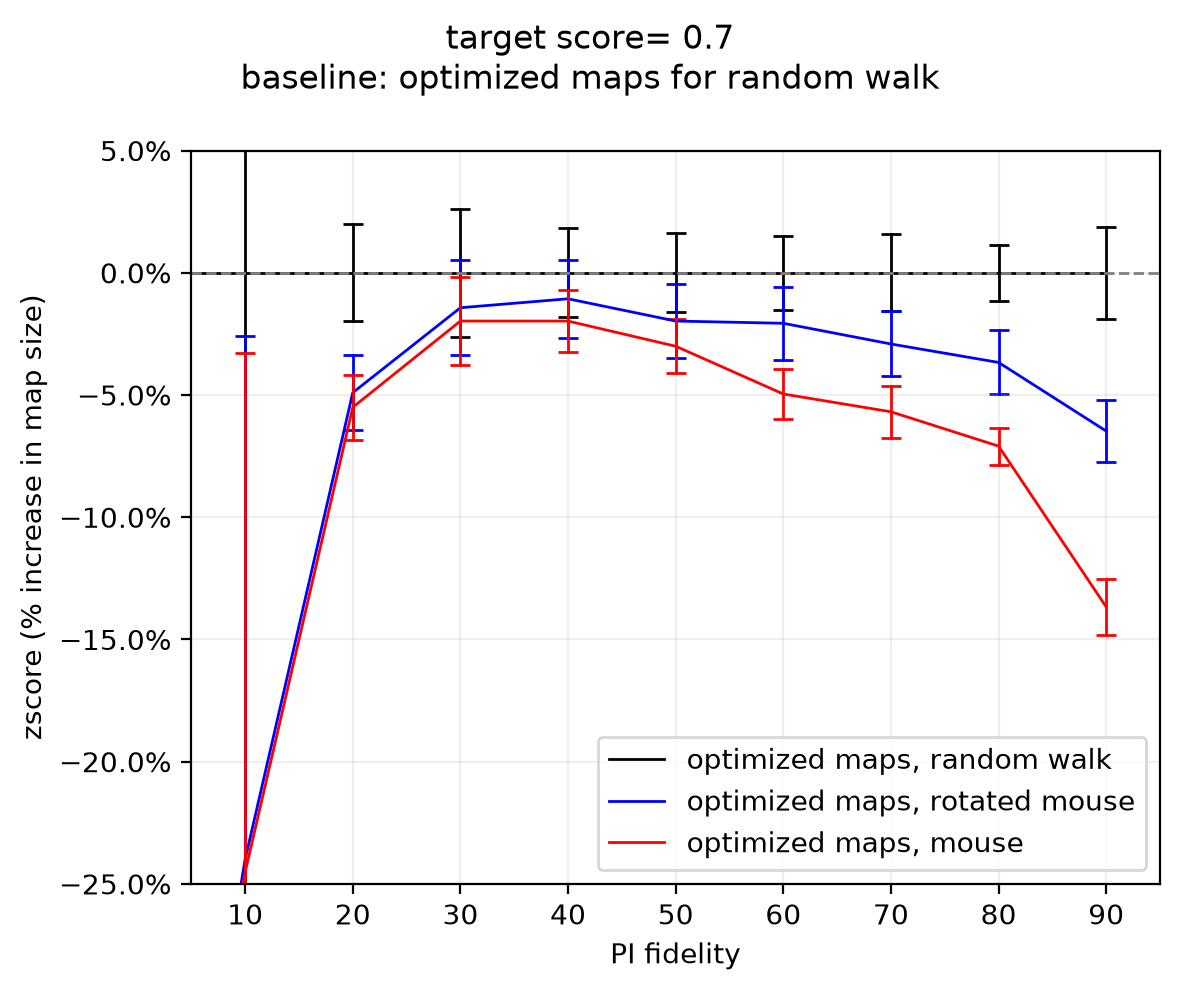

In [53]:
# prep: tradeoff curves
score_tensor_select = [score_tensor_list[x] for x in [2,1,0]]
label_select = ['optimized maps, random walk', 'optimized maps, rotated mouse', 'optimized maps, mouse']
color_select = ['k', 'b', 'r']

# baseline
mapsize_arr_rw = np.argmin(np.abs(score_tensor_select[0]-score_tar), axis=-1)
mapsize_ci_rw, mapsize_mean_rw, _ = get_confidence_interval(mapsize_arr_rw, axis=1)

# plot
plt.figure(figsize=(6,5), dpi=200)
plt.suptitle(f'target score= {score_tar}\nbaseline: optimized maps for random walk')

# plt.subplot(111)
# for i, (score_tensor, label, color) in enumerate(zip(score_tensor_select, label_select, color_select)):
#     mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
#     mapsize_ci, mapsize_mean, _ = get_confidence_interval(mapsize_arr, axis=1)
    
#     # override
#     mapsize_mean -= mapsize_mean_rw
    
#     # iter
#     plt.plot(pi_level_list, mapsize_mean, color=color, lw=1, label=label)
#     for pi, ci0, ci1 in zip(pi_level_list, mapsize_mean-mapsize_ci, mapsize_mean+mapsize_ci):
#         plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
#     plt.scatter(pi_level_list, mapsize_mean-mapsize_ci, color=color, s=50, marker='_', lw=1)
#     plt.scatter(pi_level_list, mapsize_mean+mapsize_ci, color=color, s=50, marker='_', lw=1)
# plt.axhline(0, color='gray', linestyle='--', lw=1)
# plt.xlabel('PI fidelity')
# plt.ylabel('map size - baseline (# edges)')
# plt.legend()
# plt.xlim([5, 95])
# plt.ylim([-25, 5])
# plt.grid(alpha=.2)


plt.subplot(111)
for i, (score_tensor, label, color) in enumerate(zip(score_tensor_select, label_select, color_select)):
    mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
    mapsize_ci, mapsize_mean, _ = get_confidence_interval(mapsize_arr, axis=1)
    
    # z-score
    zscore = (mapsize_mean - mapsize_mean_rw) / mapsize_mean_rw
    
    # uncertainty propagation
    # z_ci = np.sqrt((mapsize_ci / mapsize_mean_rw)**2 + (mapsize_mean * mapsize_ci_rw / mapsize_mean_rw**2)**2)
    
    z_ci = (1+zscore) * np.sqrt((mapsize_ci / mapsize_mean)**2 + (mapsize_ci_rw / mapsize_mean_rw)**2)
    
    # iter
    plt.plot(pi_level_list, zscore, color=color, lw=1, label=label)
    for pi, ci0, ci1 in zip(pi_level_list, zscore-z_ci, zscore+z_ci):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, zscore-z_ci, color=color, s=50, marker='_', lw=1)
    plt.scatter(pi_level_list, zscore+z_ci, color=color, s=50, marker='_', lw=1)
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.xlabel('PI fidelity')
plt.ylabel('zscore (% increase in map size)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.legend()
plt.xlim([5, 95])
plt.ylim([-.25, .05])
plt.grid(alpha=.2)

# setting
plt.tight_layout()

## SI FIGURE: tradeoff curves, compression rate

In [54]:
score_tar = .7

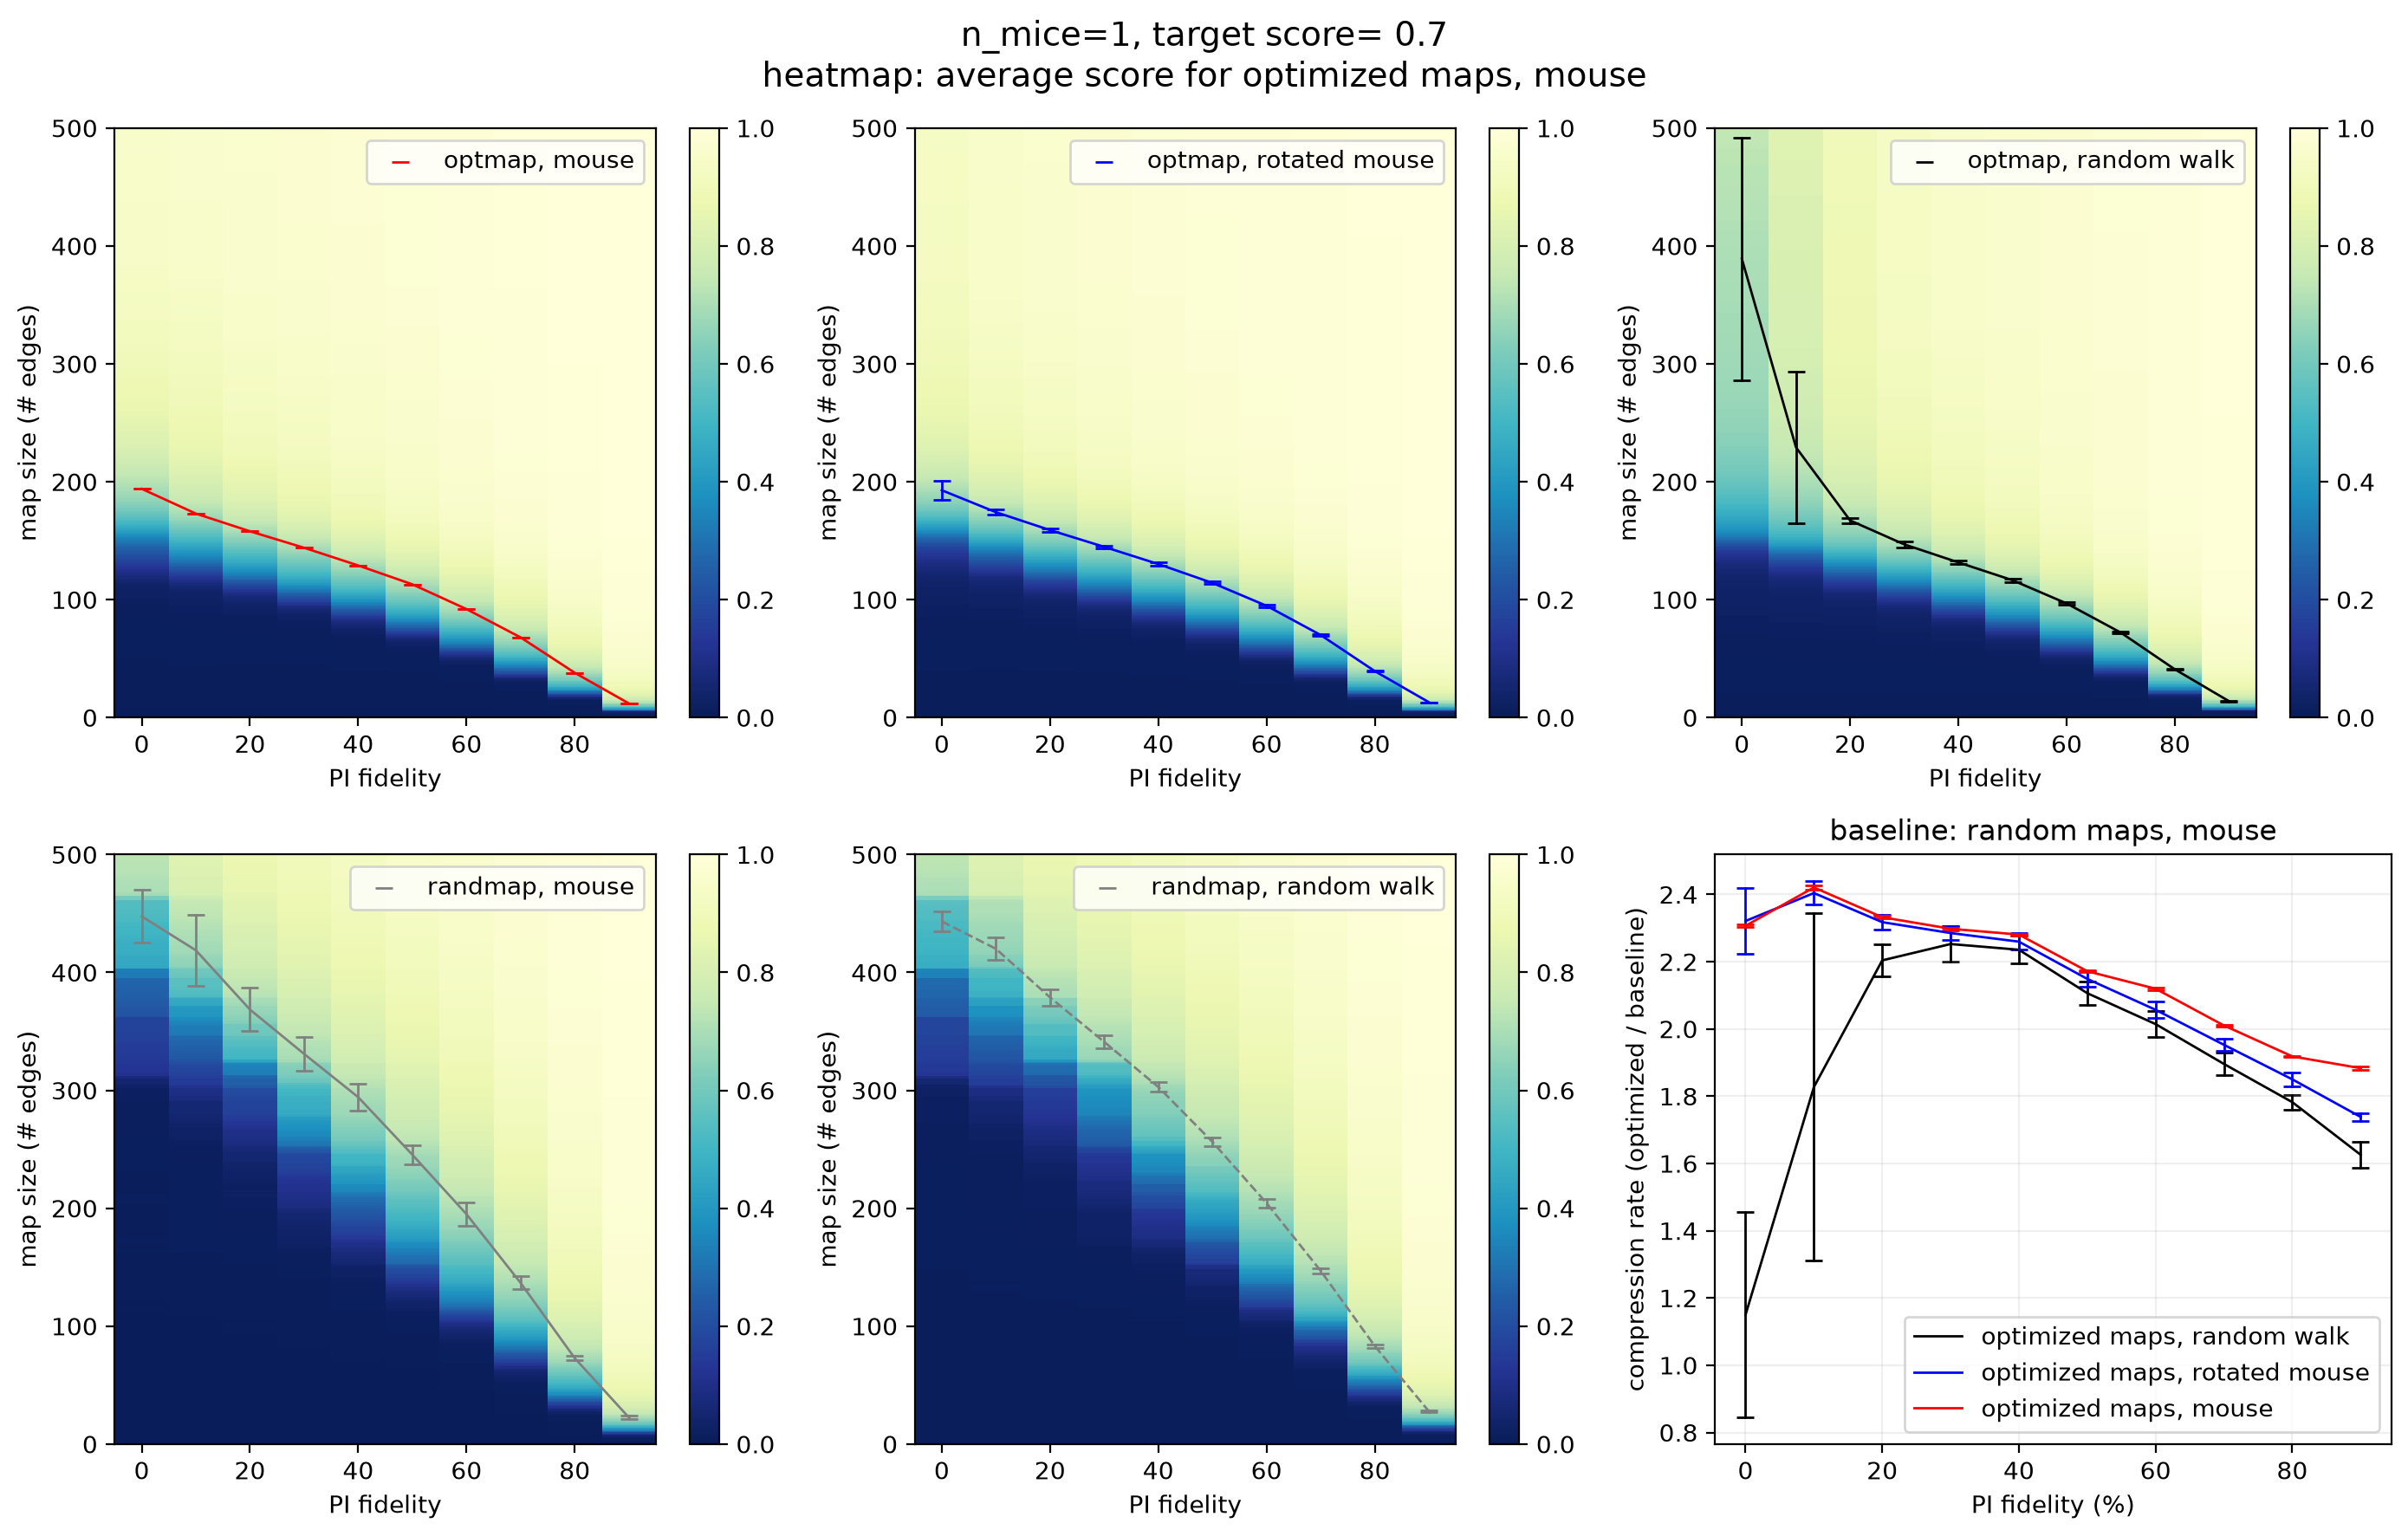

In [55]:
# prep: tradeoff curves
# score_tensor_select = [score_tensor_list[x] for x in [3, 2, 1, 0]]
# label_select = ['random maps, mouse', 'optimized maps, random walk', 'optimized maps, rotated mouse', 'optimized maps, mouse']
color_list = ['r','b','k','gray','gray']
linestyle_list = ['-', '-', '-', '-', '--']

# prep: heatmap
# score_arr = score_tensor_select[-1].mean(1)

# plot
plt.figure(figsize=(14, 9), dpi=200)
plt.suptitle(f'n_mice={n_mice}, target score= {score_tar}\nheatmap: average score for {label_select[-1]}', fontsize=14)

## HEATMAP
for i, (score_tensor, label, color) in enumerate(zip(score_tensor_list, label_list, color_list)):
    score_arr = score_tensor.mean(1)
    mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
    mapsize_ci, mapsize_mean, _ = get_confidence_interval(mapsize_arr, axis=1)
    #
    plt.subplot(2,3,i+1)
    plt.imshow(score_arr.T, aspect='auto', cmap='YlGnBu_r', origin='lower', vmin=0, vmax=1, interpolation='nearest', extent=[pi_level_list[0]-5, pi_level_list[-1]+5, 0, score_arr.shape[1]])
    plt.colorbar()
    for pi, ci0, ci1 in zip(pi_level_list, mapsize_mean-mapsize_ci, mapsize_mean+mapsize_ci):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, mapsize_mean-mapsize_ci, color=color, s=50, label=f'{label}', marker='_', lw=1)
    plt.scatter(pi_level_list, mapsize_mean+mapsize_ci, color=color, s=50, marker='_', lw=1)
    plt.plot(pi_level_list, mapsize_mean, color=color, lw=1, ls=linestyle_list[i])
    
    # zoom 0
    plt.ylim([0, 500])

    # setting
    plt.xlabel('PI fidelity')
    plt.ylabel('map size (# edges)')
    plt.legend()

## COMPRESSION RATE
# prep: tradeoff curves
score_tensor_select = [score_tensor_list[x] for x in [2,1,0]]
label_select = ['optimized maps, random walk', 'optimized maps, rotated mouse', 'optimized maps, mouse']
color_select = ['k', 'b', 'r']

# baseline
mapsize_arr = np.argmin(np.abs(score_tensor_list[3]-score_tar), axis=-1)
mapsize_ci_base, mapsize_mean_base, _ = get_confidence_interval(mapsize_arr, axis=1)

# iter
cr_list, cr_ci_list = [], []
for score_tensor in score_tensor_select:
    # get mapsize for target score
    mapsize_arr = np.argmin(np.abs(score_tensor-score_tar), axis=-1)
    mapsize_ci, mapsize_mean, _ = get_confidence_interval(mapsize_arr, axis=1)
    
    # compute compression rate
    cr = mapsize_mean_base / mapsize_mean
    
    # uncertainty propagation
    mapsize_ci_base = mapsize_ci_base * np.sqrt(2*5)/np.sqrt(9*10)
    cr_ci = cr * np.sqrt((mapsize_ci / mapsize_mean)**2 + (mapsize_ci_base / mapsize_mean_base)**2)
    
    # append
    cr_list.append(cr)
    cr_ci_list.append(cr_ci)
    
# plot
plt.subplot(2,3,6)
plt.title(f'baseline: random maps, mouse')
for i, (cr, cr_ci, label, color) in enumerate(zip(cr_list, cr_ci_list, label_select, color_select)):
    plt.plot(pi_level_list, cr, color=color, lw=1, label=label)
    for pi, ci0, ci1 in zip(pi_level_list, cr-cr_ci, cr+cr_ci):
        plt.plot([pi, pi], [ci0, ci1], color=color, lw=1)
    plt.scatter(pi_level_list, cr-cr_ci, color=color, s=50, marker='_', lw=1)
    plt.scatter(pi_level_list, cr+cr_ci, color=color, s=50, marker='_', lw=1)

# setting
plt.xlabel('PI fidelity (%)')
plt.ylabel('compression rate (optimized / baseline)')
plt.legend()
plt.grid(alpha=.2)

# global setting
plt.tight_layout()

# # zoom 1
# plt.xlim([15, 95])
# plt.ylim([0, 180])

# # zoom 2
# plt.xlim([75, 95])
# plt.ylim([0, 45])

## TEST, score map

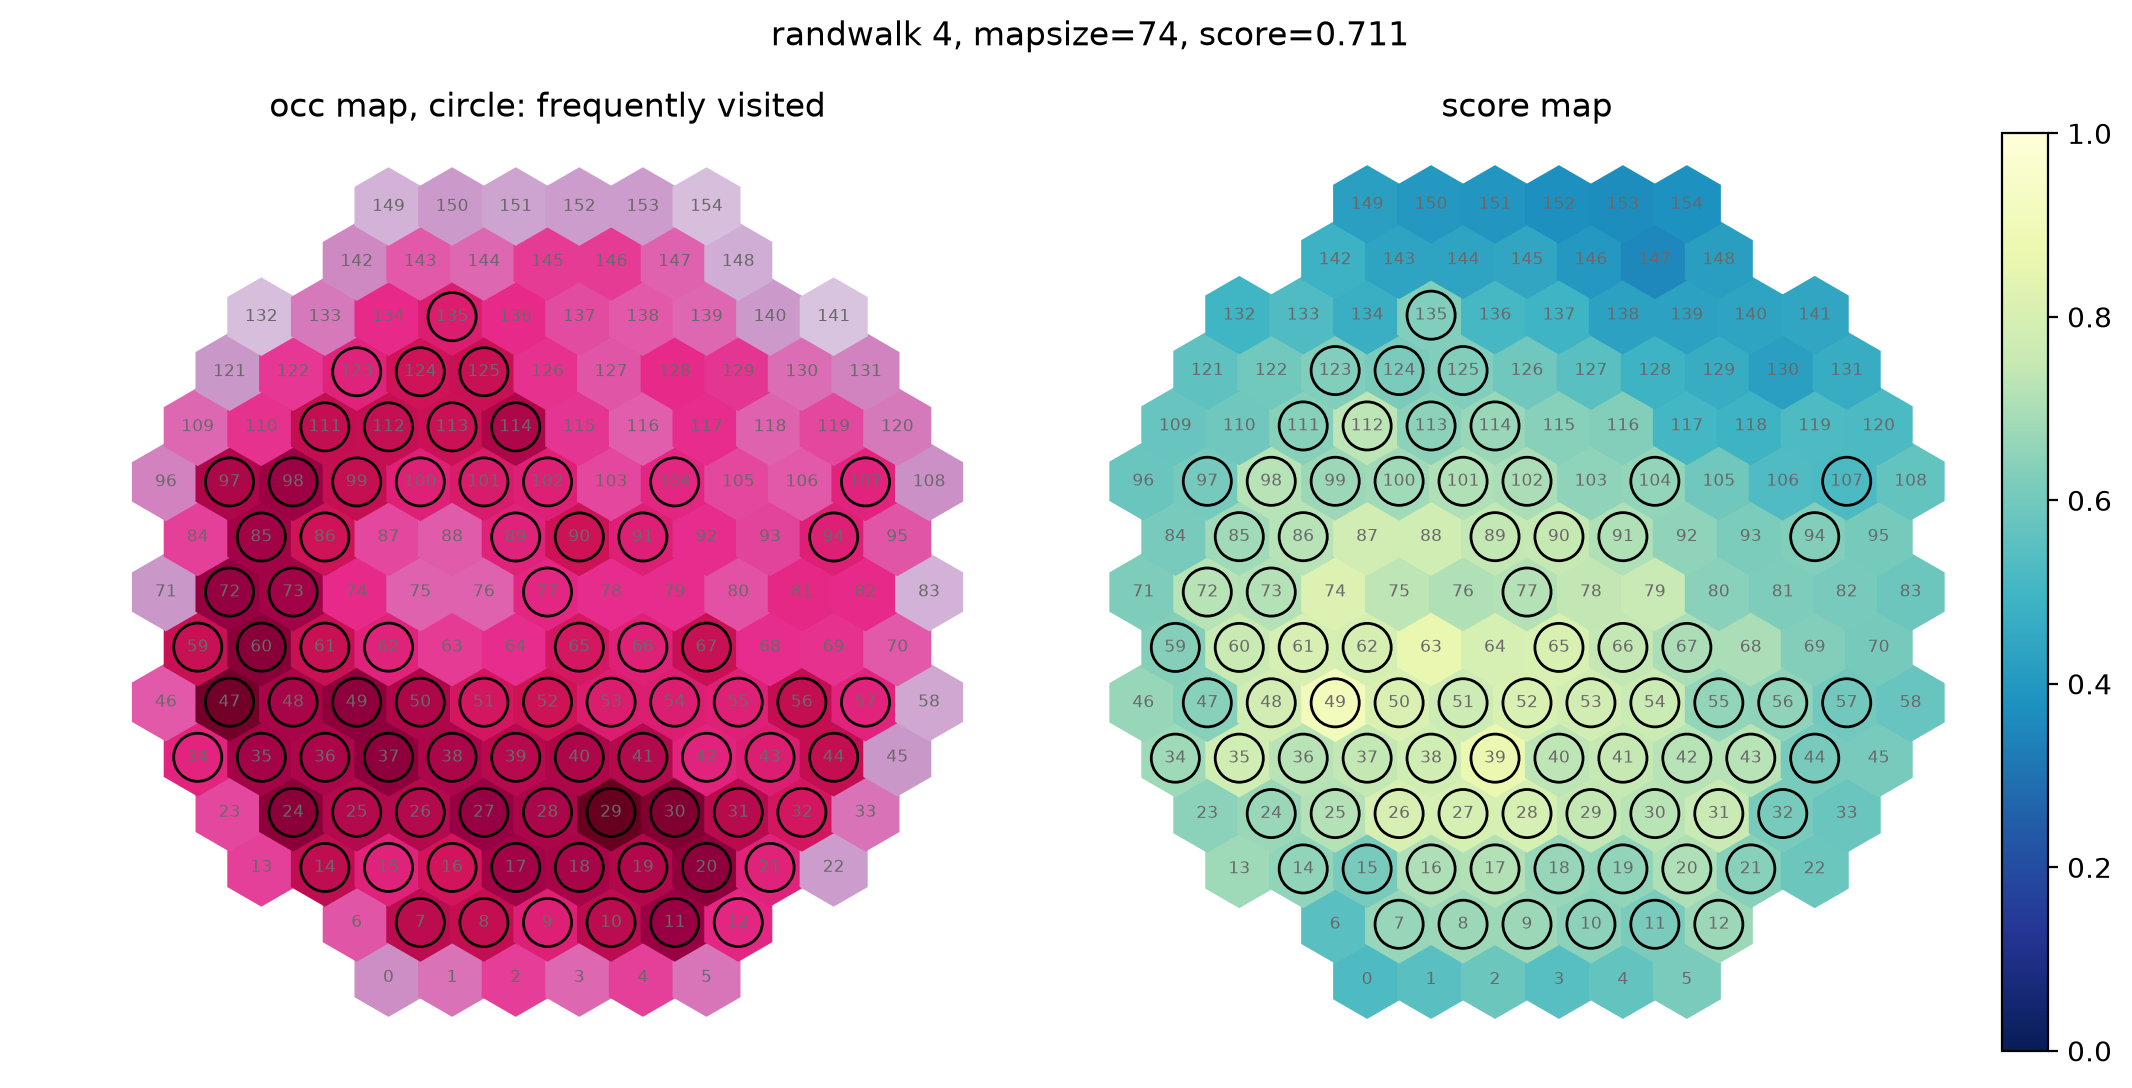

In [56]:
# job = ((1,19,0), 70)
job = ((0,4,-1), 70)
mapsize = 74

# load
# job = ((1,mouse_id,rot_id), pi_level)
# job = ((0,0,-1), pi_level)
load_dir = project_dir / "results" / "data_optmap"
score_all, score_map_all, _ = pickle.load(open(load_dir / f"dat_map_{job}", "rb"))

# load one iter
iter_select = list(range(931))[::-1].index(mapsize)
score_map = score_map_all[iter_select]
score = score_all[iter_select]

# prep
s_traj, a_traj, occ_map, s_top, xy_traj = dat_traj_dict[job[0]]
s_count = [Counter(s_traj)[x] for x in range(n_tiles)]
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T
hex_0_all, hex_1_all = np.array(list(s_hex_dict.values())).T

# plot
plt.figure(figsize=(11,5.5), dpi=200)
if job[0][0]==1:
    plt.suptitle(f'mouse {job[0][1]}, rotation {job[0][2]}, pi={job[1]}, mapsize={mapsize}, score={score:.3f}')
elif job[0][0]==0:
    plt.suptitle(f'randwalk {job[0][1]}, mapsize={mapsize}, score={score:.3f}')

# map
plt.subplot(121)
plt.title('occ map, circle: frequently visited')
plt.scatter(hex_0_all, hex_1_all, c=occ_map, cmap='PuRd', marker='h', s=800, vmin=0, edgecolor='none')
plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')
for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
plt.axis('off')
plt.axis('equal')

plt.subplot(122)
plt.title('score map')
plt.scatter(hex_0_all, hex_1_all, c=score_map, cmap='YlGnBu_r', marker='h', s=800, vmin=0, vmax=1, edgecolor='none')
plt.colorbar()
plt.scatter(hex_0_all[s_top], hex_1_all[s_top], c='none', marker='o', s=300, edgecolor='k')
for (x,y), s in xy_s_dict.items():
    plt.text(hex_0_grid[y,x], hex_1_grid[y,x], str(s), color='dimgray', fontsize=6, ha='center', va='center')
plt.axis('off')
plt.axis('equal')

# setting
plt.axis('off')
plt.tight_layout()